[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maxencegu/python-datascience/blob/main/assignments/td08_pandas_agregation_et_transformation/td08_enonce.ipynb)

⚠️ ***Gestion du temps : Le quiz de fin de séance est obligatoire et se ferme à la fin du TD. N'hésitez pas à sauter des exercices pour vous laisser 10 minutes. Tout le notebook doit être terminé avant le prochain TD.***

---

# **Introduction**

Au TD précédent, vous avez découvert **Matplotlib**, les **dictionnaires** et **Pandas**.
Vous savez maintenant produire des graphiques, structurer des données sous forme de paires clé-valeur,
et charger un jeu de données dans un DataFrame pour le sélectionner avec `[ ]`, `loc` et `iloc`.

Mais jusqu'ici, vos scripts s'exécutaient toujours du début à la fin, ligne par ligne, sans jamais
prendre de décision ni répéter une opération automatiquement.
Comment faire réagir votre code différemment selon les données ?
Comment appliquer le même traitement à des centaines de lignes sans tout réécrire ?

C'est exactement ce que vous allez apprendre dans ce TD, avec quatre outils fondamentaux.

Les **opérateurs de comparaison et booléens** permettent de formuler des conditions — égalité, inégalité,
supériorité — et de les combiner avec `and`, `or`, `not` ou leurs équivalents NumPy.

La structure **if / elif / else** permet à votre script de prendre des décisions : exécuter
un bloc de code si une condition est vraie, un autre sinon.

La **boucle while** répète un bloc tant qu'une condition reste vraie — idéale pour simuler
un processus qui converge progressivement.

La **boucle for** parcourt automatiquement chaque élément d'une séquence : liste, chaîne,
dictionnaire, tableau NumPy ou DataFrame Pandas.

Dans ce TD, vous apprendrez à :
- comparer des valeurs avec les opérateurs `==`, `!=`, `<`, `>`, `<=`, `>=` ;
- combiner des conditions avec `and`, `or`, `not` et `np.logical_and()` ;
- filtrer un DataFrame Pandas à partir d'une condition booléenne ;
- contrôler le flux d'exécution avec `if`, `elif` et `else` ;
- répéter des opérations avec les boucles `while` et `for` ;
- itérer sur des dictionnaires, des tableaux NumPy et des DataFrames Pandas.

À l'issue de cette séance, vous serez capables d'écrire des scripts qui prennent des décisions,
filtrent des données automatiquement et appliquent un traitement à l'ensemble des lignes
d'un DataFrame en quelques lignes de code.

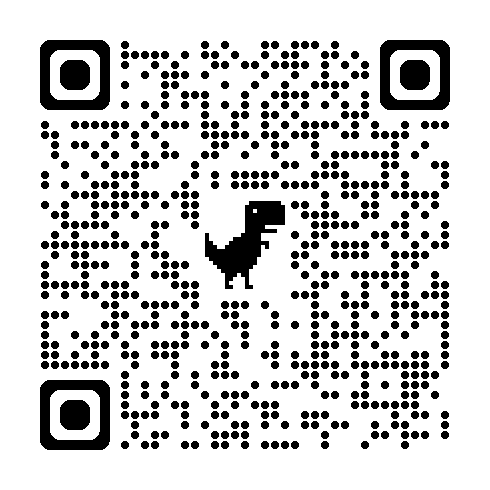

In [1]:
# @title 📋 Feuille de présence (remplir maintenant)
from IPython.display import Image, display, HTML

display(HTML('<h3 style="font-family:sans-serif;">📋 Feuille de présence</h3>'))
display(Image("https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td08_pandas_agregation_et_transformation/assets/qr_td08_presence.png", width=250))
display(HTML('<a href="https://forms.gle/X4S6x2ickHHd5Q9J9" target="_blank"><button style="font-size:15px;padding:8px 16px;margin-top:8px;cursor:pointer;">Ouvrir le formulaire</button></a>'))

In [2]:
# @title Configuration des ressources (ne pas modifier)
from IPython.display import Image, display, HTML

BASE_URL = "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td08_pandas_agregation_et_transformation/images/"

def afficher_infographie(nom_fichier, largeur=1300):
    display(Image(url=BASE_URL + nom_fichier, width=largeur))

In [3]:
# @title Infographie — Workflow Complet du TD
afficher_infographie("13_workflow_complet_td_pro.png")

# **1. Transformer des DataFrames**

Maîtrisons les bases de pandas. Apprenez à inspecter des DataFrames et à réaliser des manipulations essentielles : trier des lignes, faire des sous-ensembles et ajouter de nouvelles colonnes.

## **1.1 Présentation des Dataframes**

In [4]:
# @title Infographie — Introduction aux dataframes
afficher_infographie("01_introduction_dataframes_pro.png")

---
---

### **Exercice — Inspection d'un DataFrame**

Lorsque vous travaillez avec un nouveau DataFrame, la première chose à faire est de l'explorer pour comprendre ce qu'il contient.

Le DataFrame `homelessness` contient les estimations du nombre de sans-abri dans chacun des États américains en 2018 :
- `individual` — personnes sans domicile hors famille avec enfants
- `family_members` — personnes sans domicile en famille avec enfants
- `state_pop` — population totale de l'État

---

### **Instructions**

1. Affichez les premières lignes du DataFrame.
2. Affichez les informations sur les colonnes.
3. Affichez les dimensions du Dataframe.
4. Affichez les statistiques récapitulatives.

In [ ]:
import pandas as pd
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/datasets/homelessness.csv",
    "homelessness.csv"
)

homelessness = pd.read_csv("homelessness.csv", index_col=0)

# Print the head of the homelessness data
print(____)
# Print information about homelessness
print(____)
# Print the shape of homelessness
print(____)
# Print a description of homelessness
print(____)

---
---

### **Exercice — Éléments d'un DataFrame**

Un DataFrame pandas se compose de trois éléments accessibles séparément :

- `.to_numpy()` — les valeurs sous forme de tableau NumPy 2D
- `.columns` — les noms des colonnes
- `.index` — les étiquettes des lignes

---

### **Instructions**

1. Affichez les valeurs de `homelessness` sous forme de tableau NumPy avec `.to_numpy()`.
2. Affichez les noms de colonnes avec `.columns`.
3. Affichez l'index des lignes avec `.index`.

In [ ]:
# Import pandas using the alias pd
____

# Print the values of homelessness as a NumPy array
print(____)_

# Print the column index of homelessness
print(____)

# Print the row index of homelessness
print(____)

## **1.2 Tri et sous-ensemble**

In [5]:
# @title Infographie — Tri et subdivision
afficher_infographie("02_tri_et_subdivision_pro.png")

---

---

### **Exercice — Tri des lignes**

En triant les lignes d'un DataFrame, vous faites remonter les données les plus intéressantes. Combinez `.sort_values()` avec `.head()` pour répondre à des questions comme *"Quels sont les États avec le plus de sans-abri ?"*.

| Trier sur…         | Syntaxe                            |
|--------------------|------------------------------------|
| une colonne        | `df.sort_values("col")`            |
| plusieurs colonnes | `df.sort_values(["col1", "col2"])` |

---

### **Instructions**

1. Triez `homelessness` par `individuals` (ordre croissant), enregistrez sous `homelessness_ind` et affichez les premières lignes.
2. Triez `homelessness` par `family_members` (ordre **décroissant**), enregistrez sous `homelessness_fam` et affichez les premières lignes.
3. Triez `homelessness` par `region` (croissant) puis par `family_members` (décroissant), enregistrez sous `homelessness_reg_fam` et affichez les premières lignes.

In [ ]:
# Sort homelessness by individuals
homelessness_ind = ____
# Print the top few rows
print(____)

# Sort homelessness by descending family members
homelessness_fam = ____
# Print the top few rows
print(____)

# Sort homelessness by region, then descending family members
homelessness_reg_fam = ____
# Print the top few rows
print(____)

---

---

### **Exercice — Création de sous-ensembles de colonnes**

Les crochets `[]` permettent de sélectionner uniquement les colonnes qui vous intéressent.

| Sélection          | Syntaxe                  | Résultat  |
|--------------------|--------------------------|-----------|
| Une colonne        | `df["col_a"]`            | Series    |
| Plusieurs colonnes | `df[["col_a", "col_b"]]` | DataFrame |

---

### **Instructions**

1. Créez une Series `individuals` contenant uniquement la colonne `individuals`.
2. Créez un DataFrame `state_fam` avec les colonnes `state` et `family_members`, dans cet ordre.
3. Créez un DataFrame `ind_state` avec les colonnes `individuals` et `state`, dans cet ordre.

In [ ]:
# Select the individuals column
individuals = ____
print(individuals.head())

# Select the state and family_members columns
state_fam = ____
print(state_fam.head())

# Select only the individuals and state columns, in that order
ind_state = ____
print(ind_state.head())

---

---

### **Exercice — Création de sous-ensembles de lignes**

Pour filtrer les lignes d'un DataFrame, construisez une condition logique et passez-la entre crochets. Chaque ligne renvoie `True` ou `False` selon qu'elle satisfait la condition.

| Condition            | Syntaxe                     |
|----------------------|-----------------------------|
| Valeur numérique     | `df[df["col"] > 60]`        |
| Valeur textuelle     | `df[df["col"] == "valeur"]` |
| Plusieurs conditions | `df[(cond1) & (cond2)]`     |

> 💡 Avec plusieurs conditions, chaque condition doit être entre **parenthèses** et séparée par `&`.

---

### **Instructions**

1. Filtrez `homelessness` pour les États avec plus de 10 000 sans-abri (`individuals > 10000`), enregistrez sous `ind_gt_10k` et affichez le résultat.
2. Filtrez `homelessness` pour la région `"Mountain"`, enregistrez sous `mountain_reg` et affichez le résultat.
3. Filtrez `homelessness` pour les États de la région `"Pacific"` ayant moins de 1 000 membres de famille (`family_members < 1000`), enregistrez sous `fam_lt_1k_pac` et affichez le résultat.

In [ ]:
# Filter for rows where individuals is greater than 10000
ind_gt_10k = ____
# See the result
print(ind_gt_10k)

# Filter for rows where region is Mountain
mountain_reg = ____
# See the result
print(mountain_reg)

# Filter for rows where family_members is less than 1000
# and region is Pacific
fam_lt_1k_pac = ____
# See the result
print(fam_lt_1k_pac)

---

---

### **Exercice — Sous-ensemble par variables catégorielles**

Quand vous voulez filtrer sur plusieurs valeurs d'une même colonne, `.isin()` est plus lisible qu'une série de conditions `==` combinées avec `|`.

```python
colors = ["brown", "black", "tan"]
df[df["color"].isin(colors)]
```

---
### **Instructions**

Filtrez homelessness pour les États du désert Mojave (Californie, Arizona, Nevada, Utah), enregistrez sous mojave_homelessness et affichez le résultat.

In [ ]:
# The Mojave Desert states
canu = ["California", "Arizona", "Nevada", "Utah"]

# Filter for rows in the Mojave Desert states
mojave_homelessness = ____

# See the result
print(mojave_homelessness)

## **1.3 Nouvelles colonnes**

In [6]:
# @title Infographie — Nouvelles colonnes
afficher_infographie("03_nouvelles_colonnes_pro.png")

---

---

### **Exercice — Ajout de nouvelles colonnes**

Vous pouvez enrichir un DataFrame en créant des colonnes calculées à partir de colonnes existantes.

```python
df["nouvelle_col"] = df["col_a"] + df["col_b"]   # somme
df["proportion"]   = df["col_a"] / df["col_b"]   # ratio
```
---
### **Instructions**

1. Ajoutez une colonne total contenant la somme de individuals et family_members.
2. Ajoutez une colonne p_homeless contenant la proportion de sans-abri par rapport à la population totale (state_pop).

In [ ]:
# Add total col as sum of individuals and family_members
____

# Add p_homeless col as proportion of total homeless population to the state population
____

# See the result
print(homelessness)

---

---

### **Exercice — Attaque combinée !**

Combinez les quatre opérations apprises pour répondre à une question réelle :

> **Quel État a le plus grand nombre de sans-abri pour 10 000 habitants ?**

---

### **Instructions**

1. Ajoutez une colonne `indiv_per_10k` : nombre de sans-abri (`individuals`) pour 10 000 personnes dans chaque État (`state_pop`).
2. Filtrez les lignes où `indiv_per_10k > 20`, enregistrez sous `high_homelessness`.
3. Triez `high_homelessness` par `indiv_per_10k` décroissant, enregistrez sous `high_homelessness_srt`.
4. Sélectionnez uniquement les colonnes `state` et `indiv_per_10k`, enregistrez sous `result` et affichez.

In [ ]:
# Create indiv_per_10k col as homeless individuals per 10k state pop
homelessness["indiv_per_10k"] = 10000 * ___

# Subset rows for indiv_per_10k greater than 20
high_homelessness =___
print(high_homelessness)

# Sort high_homelessness by descending indiv_per_10k
high_homelessness_srt = ___

# From high_homelessness_srt, select the state and indiv_per_10k cols
result = ___
# See the result
print(result)

# **2. Agrégation de DataFrames**  

Dans ce chapitre, vous calculerez des statistiques récapitulatives sur les colonnes d'un DataFrame et vous apprendrez à maîtriser les statistiques groupées et les tableaux croisés dynamiques (pivot tables).

## **2.1 Boucle "while"**

In [ ]:
# @title Infographie — Boucle "while"
afficher_infographie("05_boucle_while_pro.png")

---
---
### **Exercice**

La boucle `while` est une instruction `if` répétée : le code s'exécute encore et encore **tant que la condition est `True`**.

Combien de fois la boucle suivante affiche-t-elle quelque chose ?

```python
x = 1
while x < 4:
    print(x)
    x = x + 1
```

Choisissez la bonne réponse :

- 0
- 1
- 2
- 3
- 4

In [ ]:
# Entrez le numéro de la bonne réponse (0, 1, 2, 3 ou 4)
reponse = ___

In [ ]:
# @title ✅ Exécuter la cellule pour vérifier votre réponse
EXPLICATIONS = {
    0: "Incorrect. x vaut 1 au départ, et 1 < 4 est True : la boucle s'exécute bien.",
    1: "Incorrect. La boucle tourne jusqu'à ce que x atteigne 4, pas seulement une fois.",
    2: "Incorrect. La boucle affiche x=1, x=2 et x=3 — comptez à nouveau.",
    3: "Correct ! x prend les valeurs 1, 2 puis 3 (3 affichages). Quand x=4, la condition 4 < 4 est False : la boucle s'arrête.",
    4: "Incorrect. Quand x=4, la condition x < 4 est False : la boucle s'arrête sans afficher 4.",
}

try:
    r = int(reponse)
    if r == 3:
        print(f"✅ Bonne réponse ({r}) : {EXPLICATIONS[r]}")
    elif r in EXPLICATIONS:
        print(f"❌ Réponse {r} incorrecte : {EXPLICATIONS[r]}")
    else:
        print(f"❌ Réponse non reconnue : {reponse!r} — attendu un nombre entre 1 et 5")
except NameError:
    print("❌ reponse n'est pas défini — attribuez un nombre à la variable reponse")
except (ValueError, TypeError):
    print(f"❌ reponse doit être un nombre (1 à 5) — valeur reçue : {reponse!r}")

---
---
### **Exercice**

Vous allez coder une boucle `while` pour simuler un **système de correction de pendule inversé** : tant qu'il y a un décalage par rapport à la position droite, la boucle corrige progressivement ce décalage.

---
### **Instructions**
1. Créez la variable `offset` avec la valeur initiale `8`.
2. Écrivez une boucle `while` qui tourne tant que `offset` n'est pas égal à `0`.
   À l'intérieur de la boucle :
   - Affichez `"correcting..."`.
   - Diminuez `offset` de `1`.
   - Affichez la nouvelle valeur de `offset`.

In [ ]:
# Initialize offset
____

# Code the while loop
____
____
____
____

---
---
### **Exercice**

Si `offset` est **négatif**, la boucle précédente tourne à l'infini : `offset` diminue sans jamais atteindre `0`.

La solution : ajouter un `if-else` à l'intérieur de la boucle pour corriger dans le **bon sens** selon le signe d'`offset`.

---
### **Instructions**
1. Initialisez `offset` à `-6`.
2. Complétez le `if-else` à l'intérieur de la boucle :
   - Si `offset > 0` → diminuez `offset` de `1`.
   - Sinon → augmentez `offset` de `1`.

In [ ]:
# Initialize offset
offset = -6

# Code the while loop
while offset != 0 :
    print("correcting...")
    if ____ :
      ____
    else :
      ____
    print(offset)

## **2.2 Boucle "for"**

In [ ]:
# @title Infographie — Boucle "for"
afficher_infographie("06_boucle_for_pro.png")

---
---
### **Exercice**

La boucle `for` parcourt automatiquement chaque élément d'une liste, l'un après l'autre.

```python
fam = [1.73, 1.68, 1.71, 1.89]
for height in fam:
    print(height)
```
---
### **Instructions**
Écrivez une boucle for qui parcourt tous les éléments de areas et affiche chaque élément séparément.

In [ ]:
# areas list
areas = [11.25, 18.0, 20.0, 10.75, 9.50]

# Code the for loop
____
____

---
---
### **Exercice**

`enumerate()` permet d'accéder simultanément à **l'indice** et à la **valeur** de chaque élément :

```python
fam = [1.73, 1.68, 1.71, 1.89]
for index, height in enumerate(fam):
    print("person " + str(index) + ": " + str(height))
```
---
### **Instructions**
Adaptez la boucle for sur areas pour utiliser enumerate() et afficher une ligne de la forme :
room 0: 11.25
room 1: 18.0
… et ainsi de suite.

In [ ]:
# areas list
areas = [11.25, 18.0, 20.0, 10.75, 9.50]

# Change for loop to use enumerate() and update print()
for x in areas:
    print(x)

---
---
### **Exercice**

Les indices Python commencent à `0`, mais pour un affichage lisible, il est parfois préférable de commencer à `1`.

---
### **Instructions**
Modifiez le `print()` pour que l'affichage commence à `room 1` au lieu de `room 0` :
`room 1: 11.25`
`room 2: 18.0`
… et ainsi de suite.

In [ ]:
# areas list
areas = [11.25, 18.0, 20.0, 10.75, 9.50]

# Code the for loop
for index, area in enumerate(areas) :
    print("room " + str(index) + ": " + str(area))

---
---
### **Exercice**

La variable `house` est une liste de listes : chaque sous-liste contient le nom d'une pièce et sa superficie.

```python
house = [["hallway", 11.25],
         ["kitchen", 18.0],
         ["living room", 20.0],
         ["bedroom", 10.75],
         ["bathroom", 9.50]]
```

Lorsqu'on itère sur une liste de listes, chaque élément room est lui-même une liste de deux valeurs que l'on peut déballer en deux variables : for x, y in house.

---
### **Instructions**

Écrivez une boucle for qui parcourt chaque sous-liste de house et affiche :
the hallway is 11.25 sqm
the kitchen is 18.0 sqm
… et ainsi de suite.

In [ ]:
# house list of lists
house = [["hallway", 11.25],
         ["kitchen", 18.0],
         ["living room", 20.0],
         ["bedroom", 10.75],
         ["bathroom", 9.50]]

# Build a for loop from scratch
____
____


## **2.3 Structure de données en boucle - Partie 1**

In [ ]:
# @title Infographie — Structure de données en boucle - Partie 1
afficher_infographie("07_boucles_structures_donnees_pro.png")

---
---
### **Exercice**

Pour parcourir un dictionnaire et accéder simultanément aux clés et aux valeurs, on utilise la méthode `.items()` :

```python
for key, value in world.items():
    print(key + " -- " + str(value))
```

Le dictionnaire europe contient des pays européens comme clés et leurs capitales comme valeurs.

---
### **Instructions**

Écrivez une boucle for qui parcourt chaque paire clé/valeur de europe et affiche :
the capital of france is paris
the capital of germany is berlin
… et ainsi de suite.

In [ ]:
# Definition of dictionary
europe = {'spain':'madrid', 'france':'paris', 'germany':'berlin',
          'norway':'oslo', 'italy':'rome', 'poland':'warsaw', 'austria':'vienna' }

# Iterate over europe
____
____

---
---
### **Exercice**

Pour un tableau NumPy **1D**, la boucle `for` classique suffit. Pour un tableau **2D**, il faut `np.nditer()` pour accéder à chaque élément individuellement — sans ça, la boucle itère sur les lignes entières.

```python
for x in my_array:          # 1D — élément par élément
    ...

for x in np.nditer(my_array):   # 2D — élément par élément
    ...
```

---
### **Instructions**

1. Importez numpy sous l'alias np.
2. Écrivez une boucle for sur np_height qui affiche "x inches" pour chaque valeur.
3. Écrivez une boucle for sur np_baseball avec np.nditer() qui affiche chaque élément.

In [ ]:
# Import numpy as np
____

np_height = np.array([74, 74, 72, 72, 73, 69, 69, 71, 76, 71])

np_baseball = np.array([[74, 180],
                        [74, 215],
                        [72, 210],
                        [72, 188],
                        [73, 176],
                        [69, 209],
                        [69, 200],
                        [71, 231],
                        [76, 180],
                        [71, 188]])
# For loop over np_height
____
____

# For loop over np_baseball
____
____

## **2.4 Structure de données en boucle - Partie 2**

In [ ]:
# @title Infographie — Structure de données en boucle - Partie 2
afficher_infographie("08_boucles_dataframes_pro.png")

---
---
### **Exercice**

Pour itérer sur les lignes d'un DataFrame Pandas, on utilise `.iterrows()`. À chaque tour de boucle, deux éléments sont disponibles : le libellé de la ligne et son contenu sous forme de Series.

```python
for lab, row in brics.iterrows():
    ...
```
Le DataFrame cars contient des informations sur sept pays : nombre de voitures par habitant (cars_per_cap), nom du pays (country) et sens de conduite (drives_right).

---
### **Instructions**

Écrivez une boucle for qui parcourt les lignes de cars et, à chaque itération, affiche :
1. Le libellé de la ligne (ex. US, AUS…)
2. Le contenu complet de la ligne

In [ ]:
# Import cars data
import pandas as pd
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/datasets/cars.csv",
    "cars.csv"
)
cars = pd.read_csv('cars.csv', index_col = 0)

# Iterate over rows of cars
____
____
____

---
---
### **Exercice**

Les données de ligne générées par `iterrows()` sont des Series Pandas. On peut en extraire une valeur par son nom de colonne :

```python
for lab, row in brics.iterrows():
    print(row['country'])
```
---
### **Instructions**

Adaptez la boucle for pour afficher à chaque itération une ligne de la forme "US: 809" — c'est-à-dire le libellé de ligne suivi de cars_per_cap.

Le résultat attendu :

US: 809

AUS: 731

JPN: 588

IN: 18

RU: 200

MOR: 70

EG: 45

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Adapt for loop
for lab, row in cars.iterrows() :
    print(lab)
    print(row)

---
---
### **Exercice**

Dans une boucle `iterrows()`, on peut écrire dans le DataFrame à l'aide de `loc` pour ajouter une nouvelle colonne calculée ligne par ligne :

```python
for lab, row in brics.iterrows():
    brics.loc[lab, "name_length"] = len(row["country"])
```

---

### **Instructions**

1. Utilisez une boucle for pour ajouter une colonne "COUNTRY" contenant le nom du pays en majuscules (utilisez .upper()).
2. Affichez cars après la boucle (sans indentation) pour vérifier le résultat.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Code for loop that adds COUNTRY column
____
____

# Print cars
print(____)

---
---
### **Exercice**

La méthode `apply()` est plus efficace qu'une boucle `iterrows()` pour transformer une colonne entière. Elle applique une fonction à chaque valeur sans créer de Series intermédiaire :

```python
# Avec iterrows() — moins efficace
for lab, row in brics.iterrows():
    brics.loc[lab, "name_length"] = len(row["country"])

# Avec apply() — plus efficace
brics["name_length"] = brics["country"].apply(len)
```

Pour appeler une méthode comme .upper() avec apply(), on utilise str.upper (sans parenthèses).

---
### **Instructions**

1. Remplacez la boucle for par une seule ligne utilisant .apply(str.upper) pour créer la colonne "COUNTRY".
2. Affichez cars pour vérifier le résultat.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Use .apply(str.upper)
for lab, row in cars.iterrows() :
    cars.loc[lab, "COUNTRY"] = row["country"].upper()

In [ ]:
# @title 🧠 Quiz de fin de séance
from IPython.display import Image, display, HTML

display(HTML('<h3 style="font-family:sans-serif;">🧠 Quiz fin de séance</h3>'))
display(Image("https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td06_Logique_flux_de_controle_filtrage_et_boucles/assets/qr_td06_quiz.png", width=250))
display(HTML('<a href="https://forms.gle/quJhqGE9syv3YtYJ9" target="_blank"><button style="font-size:15px;padding:8px 16px;margin-top:8px;cursor:pointer;">Ouvrir le quiz</button></a>'))